In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import os,sys
from tqdm import tqdm
import random as random
from scipy import optimize
from scipy.stats import multivariate_normal

sys.path.insert(0, os.path.abspath(".."))
from Parametric.utils_model_design import generate_owub_design
from Parametric.utils_plot import plot_MOM_est,plot_conf_bias_sd
from Parametric.clt_fullsib import clt_joint_fullsib,clt_seq_fullsib 


# Full sibling model with three unknown parameters

This notebook reproduces the simulation presented in Section 3.1.

## Model Setup

Consider a design with $I$ families of sizes $J = (J_1, \dots, J_I)^T \in \mathbb{R}^I$, totaling $n = \sum_{i=1}^I J_i$ individuals. Let $Y\in\mathbb{R}^{n\times p}$ denote the matrix obtained by stacking the trait measurements for each individual by row. The model can then be compactly expressed as 
$$Y=U_1\alpha_1+U_2\alpha_2,$$
where each $\alpha_r$ represents the $r$-th level of random effect, with i.i.d. rows each distributed as $N(0,\Sigma_r)$. The block-diagonal matrix $U_1=\text{diag}(\mathbb{1}_{J_1},\ldots,\mathbb{1}_{J_I})\in\mathbb{R}^{n\times I}$  assigns
each sibling to the corresponding family, where each column $i$ specifies the $J_i$ siblings belonging to family $i$, and $U_2=\text{Id}_n$ is the membership matrix that assigns each individual to the corresponding individual effect.

Let 
$$B_1=U_1(U_1^TU_1)^{-1}U_1^T,\quad B_2= \text{Id}_n-U_1(U_1^TU_1)^{-1}U_1^T,$$
and consider the sum of squares matrices
$$
S_1= \frac{1}{p}Y^TB_1Y,\quad S_2= \frac{1}{p}Y^TB_2Y.
$$

Assume that $\Sigma_1$ and $\Sigma_2$ take the following form:
\begin{align*}
	\Sigma_1 = V_1\left[ \begin{array}{cc}
		\tau_1 1_{\lceil p \rho \rceil } & 0 \\
		0 &0
	\end{array} \right]V_1^T,\quad \Sigma_2 = V_2\left[ \begin{array}{cc}
		\tau_2 1_{\lceil 0.8p \rceil } & 0 \\
		0 &0
	\end{array} \right]V_2^T,
\end{align*}
where $\tau_1,\tau_2>0$ and $\rho\in(0,1)$ are unknown parameters.

We consider five scenarios that differ in eigenvector structure and estimation strategy.


- Scenario 1. $V_1=V_2=\text{Id}_p$; sequential estimation of $\theta_2=(\tau_2)$ and $\theta_1=(\tau_1,\rho)$.
- Scenario 2. $V_1=V_2=\text{Id}_p$; joint estimation of $\theta=(\tau_1,\rho,\tau_2)$.
- Scenario 3. $V_1=R(\phi)$, $V_2=\text{Id}_p$; joint estimation without simultaneous diagonalizability. 
- Scenario 4. $V_1=R(\phi)$, $V_2=\text{Id}_p$; empirical-fix procedure.
- Scenario 5. $V_1=R(\phi)$, $V_2=\text{Id}_p$; oracle-fix procedure.

In [2]:
k = 2; I = 1000; p=500; 

tau1 = 1.; rho = 0.5; tau2 = 0.5
rho0 = 0.8 # known
theta_true = np.array([tau1, rho, tau2])

U_list, B_list, J_list, n = generate_owub_design(I=I, include_intercept=False)

Sigma1_diag = np.array([tau1]*int(p*rho)+[0]*(p-int(p*rho)))
Sigma2_diag = np.array([tau2]*int(p*rho0)+[0]*(p-int(p*rho0)))
Sigma_diag_list_scenario12 = [Sigma1_diag,Sigma2_diag]
Sigma1_scenario12 = np.diag(Sigma1_diag)
Sigma2_scenario12 = np.diag(Sigma2_diag)

eta=np.pi/4
Q = np.cos(eta)*np.eye(p)+np.sin(eta)*np.fliplr(np.diag([-1]*int(p/2)+[1]*int(p/2)))
Sigma1_scenario345 = Q@np.diag(Sigma1_diag)@Q.T
Sigma2_scenario345 = np.diag(Sigma2_diag)

cache = f"k_{k}_I_{I}_p_{p}_n_{n}_"
cache+="theta_1_"+str([round(tau1,1), round(rho,1)])+"_theta_2_"+str([round(tau2,1)])
if not os.path.exists('cache/'+cache+'/'):
    os.makedirs('cache/'+cache+'/')
    os.makedirs('image/'+cache+'/')
print('cache: ',cache)

cache:  k_2_I_1000_p_500_n_1506_theta_1_[1.0, 0.5]_theta_2_[0.5]


## Compute $F_n$

As discussed in Section 3, for Scenario 1, we can analytically invert $F_n$, and for Scenarios 2-4, we numerically invert it. 

In [3]:
B=B_list[0]
F1 = torch.tensor(B @ U_list[0] @ U_list[0].T); F2 = torch.tensor(B @ U_list[1] @ U_list[1].T)
F_trace = [torch.trace(F1)/p,torch.trace(F2)/p,
           torch.trace(F1@F1)/p,torch.trace(F1@F2)/p,torch.trace(F2@F2)/p,
           torch.trace(F1@F1@F1)/p,torch.trace(F1@F1@F2)/p,torch.trace(F1@F2@F2)/p,torch.trace(F2@F2@F2)/p]

def Fn_seq(params):
    tau1, rho, tau3 = params
    F1 = torch.tensor(B_list[0] @ U_list[0] @ U_list[0].T); F2 = torch.tensor(B_list[0] @ U_list[1] @ U_list[1].T)
    x = [rho*tau1,rho0*tau3, rho*tau1**2, tau1*tau3*torch.min(rho,torch.tensor(rho0)),rho0*tau3**2]
    m1 = (torch.trace(F1)/p)*x[0] + torch.trace(F2)/p*x[1]
    m2 = ((torch.trace(F1@F1)/p)*x[0]**2 + 2 * (torch.trace(F1@F2)/p)*x[0]*x[1]+ (torch.trace(F2@F2)/p)*x[1]**2 
          + (torch.trace(F1)/p)**2*x[2] + 2*(torch.trace(F1)/p)*(torch.trace(F2)/p)*x[3] + (torch.trace(F2)/p)**2*x[4])
    m3 = (n-I)/p*rho0*tau3
    return torch.stack([m1, m2, m3])

def avg_trace_s5(rho_hat):
    t1 = np.cos(eta)**2
    t2 = np.sin(eta)**2
    if rho_hat<rho0:
        if rho_hat<1-rho0:
            return t1*rho_hat
        return t1*rho_hat+t2*(rho_hat+rho0-1)
    return t1*rho0+t2*(rho_hat+rho0-1)

def Fn_joint(params,scenario,mat_eigvec1=None,mat_eigvec2=None,F_trace=F_trace):
    tau1, rho, tau2 = params 
    if scenario == '2' or scenario== '3':
        avg_trace=rho
    if scenario == '4':
        A = mat_eigvec1.T@mat_eigvec2
        avg_trace = np.trace(A[:min(int(p*rho),p),:min(int(p*rho0),p)]@A[:min(int(p*rho),p),:min(int(p*rho0),p)].T)/p
    if scenario == '5':
        avg_trace = avg_trace_s5(rho)

    x = [rho*tau1,rho0*tau2, 
         rho*tau1**2, tau1*tau2*avg_trace,rho0*tau2**2,
         rho*tau1**3, tau1**2*tau2*avg_trace, 
         tau1*tau2**2*avg_trace,rho0*tau2**3]
    F1_1,F2_1,F1_2,F1F2,F2_2,F1_3,F1_2_F2,F1_F2_2,F2_3=F_trace
    m1 = F1_1*x[0] + F2_1*x[1]
    m2 = (F1_2*x[0]**2 + 2*F1F2*x[0]*x[1]+ F2_2*x[1]**2 
          + F1_1**2*x[2] + 2*F1_1*F2_1*x[3] + F2_1**2*x[4])
    m3 = (F1_3*x[0]**3 + 3*F1_2_F2*x[0]**2*x[1] + 3*F1_F2_2*x[0]*x[1]**2+ F2_3*x[1]**3
          + 3*F1_1*F1_2*x[0]*x[2]+ 3*F1_2*F2_1*x[0]*x[3]+ 3*F1_1*F1F2*x[0]*x[3]+ 3*F2_1*F1F2*x[0]*x[4]
          + 3*F1_1*F1F2*x[1]*x[2]+ 3*F1_1*F2_2*x[1]*x[3]+ 3*F2_1*F1F2*x[1]*x[3]+ 3*F2_1*F2_2*x[1]*x[4]
          + F1_1**3*x[5] + 3*F1_1**2*F2_1*x[6]+ 3*F1_1*F2_1**2*x[7] + F2_1**3*x[8])
    return np.array([m1, m2, m3])

In [4]:
def Fn_seq_inv(mu_hat,F_trace=F_trace):
    '''
    mu = [mu_1^{(1)},mu_1^{(2)},mu_2]
    '''
    mu1_1,mu1_2,mu2 = mu_hat
    tau_2_hat = p/(n-I) * mu2 /rho0

    F1_1,F2_1,F1_2,_,F2_2,_,_,_,_=F_trace
    term1 = (mu1_2 - (F2_2*(tau_2_hat*rho0)**2 + F2_1**2*tau_2_hat**2*rho0))/F1_1/(mu1_1-F2_1*rho0*tau_2_hat)
    term2 = F1_2*(mu1_1-F2_1*rho0*tau_2_hat)/F1_1**3
    term3 = 2*rho0*tau_2_hat/F1_1
    A = term1 - term2 - term3 
    b =  -2*F2_1/F1_1*tau_2_hat
    c = F1_1*rho0/(mu1_1-F2_1*rho0*tau_2_hat)
    if (A+b)*c >= 1:
        tau_1_hat = A+b
    else:
        tau_1_hat = A/(1-b*c)
    rho_hat = (mu1_1-F2_1*rho0*tau_2_hat)/F1_1/tau_1_hat

    theta_hat_seq = np.array([tau_1_hat,rho_hat,tau_2_hat])  
    return theta_hat_seq

def ratio_transform(a):
    out = np.empty_like(a)
    out[0] = a[0]
    out[1:] = a[1:] / a[:-1]
    return out

def Fn_joint_inverse(mu_hat,scenario,thresh=0.01,mat_eigvec1=None,mat_eigvec2=None):
    mu_hat_transformed = mu_hat.copy()
    mu_hat_transformed[1:]=mu_hat_transformed[1:]/mu_hat_transformed[:-1]
    theta_hat = np.array([1.,1.,1.])
    Fn_transformed = lambda theta: ratio_transform(Fn_joint(theta,scenario=scenario, mat_eigvec1=mat_eigvec1,mat_eigvec2=mat_eigvec2))
    while (np.linalg.norm(Fn_transformed(theta_hat) - mu_hat_transformed) > thresh) or (np.any(theta_hat < -0.5)):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            theta_hat = optimize.fsolve(lambda  x: Fn_transformed(x) - mu_hat_transformed,
                                        np.random.uniform(0, 1, size=len(mu_hat_transformed)),maxfev=5000)
    return theta_hat

# Simulations

In [5]:
# Scenarios 1 and 2: Corretly speccified, Sequential & Joint estimation
rep = 1000

def cache_MOM(seed, theta_hat, filename):
    file1 = open(os.path.join('cache/'+cache+'/', filename+".txt"), "a")
    file1.write("\n")
    file1.write(str(seed)+","+str(theta_hat.tolist()))
    file1.close()
    return 

def run_iteration(seed=1,ifcache=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    alpha1 = multivariate_normal.rvs(mean=np.zeros(p), cov=Sigma1_scenario12, size=I)
    alpha2 = multivariate_normal.rvs(mean=np.zeros(p), cov=Sigma2_scenario12, size=n)

    Y = U_list[0]@alpha1 + U_list[1]@alpha2
    S_n1 = 1/p * Y.T @ B_list[0] @ Y

    # Sequantial estimation
    Y_2 = U_list[1]@alpha2
    S_n2 = 1/p * Y_2.T @ B_list[1] @ Y_2

    mu_hat_seq = np.array([np.trace(S_n1)/p, np.trace(S_n1@S_n1)/p, np.trace(S_n2)/p])
    theta_hat_seq = Fn_seq_inv(mu_hat_seq)

    # Joint estimation
    mu_hat_joint = np.array([np.trace(S_n1)/p, np.trace(S_n1@S_n1)/p, np.trace(S_n1@S_n1@S_n1)/p])
    theta_hat_joint = Fn_joint_inverse(mu_hat_joint,scenario='2')

    if ifcache:
        cache_MOM(seed, theta_hat_seq, filename="MoM_est_scenario_1")
        cache_MOM(seed, theta_hat_joint, filename="MoM_est_scenario_2")
    return theta_hat_seq,theta_hat_joint 

theta_hat_list_scenario1= []
theta_hat_list_scenario2= []
for seed in tqdm(range(rep), desc="simulations"):
    theta_hat_seq, theta_hat_joint  = run_iteration(seed=seed,ifcache=True)
    theta_hat_list_scenario1.append(theta_hat_seq)
    theta_hat_list_scenario2.append(theta_hat_joint)


simulations: 100%|██████████| 1000/1000 [08:10<00:00,  2.04it/s]


In [6]:
# Scenarios 3, 4, 5: Misspecified, w/o fix, empirical fix, oracle fix
def run_iteration_misspecified(seed=1,ifcache=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    alpha1 = multivariate_normal.rvs(mean=np.zeros(p), cov=Sigma1_scenario345, size=I)
    alpha2 = multivariate_normal.rvs(mean=np.zeros(p), cov=Sigma2_scenario345, size=n)

    Y = U_list[0]@alpha1 + U_list[1]@alpha2
    S_n1 = 1/p * Y.T @ B_list[0] @ Y
    S_n2 = 1/p * Y.T @ B_list[1] @ Y
    
    mu_hat_joint = np.array([np.trace(S_n1)/p, np.trace(S_n1@S_n1)/p, np.trace(S_n1@S_n1@S_n1)/p])
    # Joint estimations without empirical fix
    theta_hat_nofix = Fn_joint_inverse(mu_hat_joint,scenario='3')

    # empirical fix
    Sigma1_MANOVA = p/n*(S_n1-I/(n-I)*S_n2)
    Sigma2_MANOVA = p/(n-I)*S_n2

    eigvals, eigvecs = np.linalg.eigh(Sigma1_MANOVA)
    idx = np.argsort(eigvals)[::-1] 
    eigvecs = eigvecs[:, idx]

    eigvals2, eigvecs2 = np.linalg.eigh(Sigma2_MANOVA) 
    idx = np.argsort(eigvals2)[::-1]  
    eigvecs2 = eigvecs2[:, idx]

    theta_hat_fix = Fn_joint_inverse(mu_hat_joint, scenario ='4', mat_eigvec1=eigvecs,mat_eigvec2=eigvecs2)

    # oracle fix
    theta_hat_oraclefix = Fn_joint_inverse(mu_hat_joint, scenario ='5')

    if ifcache:
        cache_MOM(seed, theta_hat_nofix, filename="MoM_est_scenario_3")
        cache_MOM(seed, theta_hat_fix, filename="MoM_est_scenario_4")
        cache_MOM(seed, theta_hat_oraclefix, filename="MoM_est_scenario_5")
    return theta_hat_nofix, theta_hat_fix, theta_hat_oraclefix

for seed in tqdm(range(rep), desc="simulations"):
    run_iteration_misspecified(seed=seed,ifcache=True)

simulations: 100%|██████████| 1000/1000 [19:17<00:00,  1.16s/it]


1000  replications


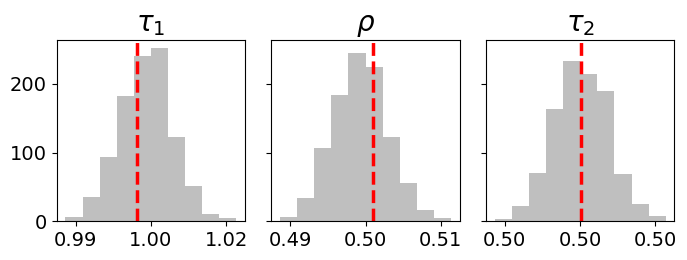

sim bias:  [0.002, -0.001, -0.0]
sim sd:  [0.0056, 0.0022, 0.0016]
1000  replications


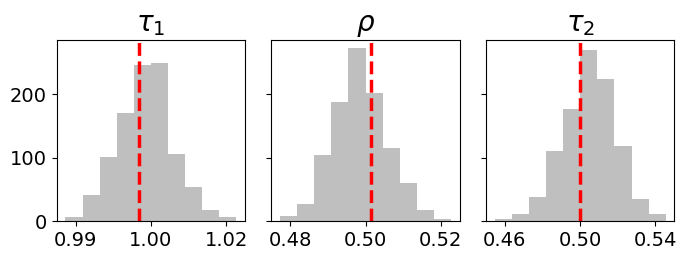

sim bias:  [0.0012, -0.0031, 0.0047]
sim sd:  [0.0049, 0.0073, 0.0136]
1000  replications


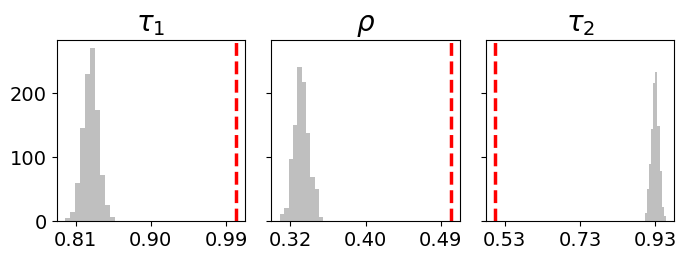

sim bias:  [-0.176, -0.1693, 0.4283]
sim sd:  [0.0091, 0.0084, 0.0096]
1000  replications


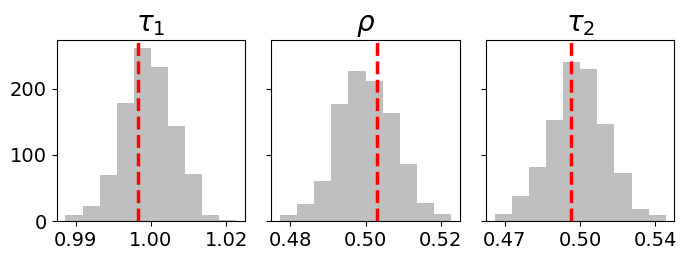

sim bias:  [0.0021, -0.0028, 0.0033]
sim sd:  [0.0051, 0.0078, 0.0136]
1000  replications


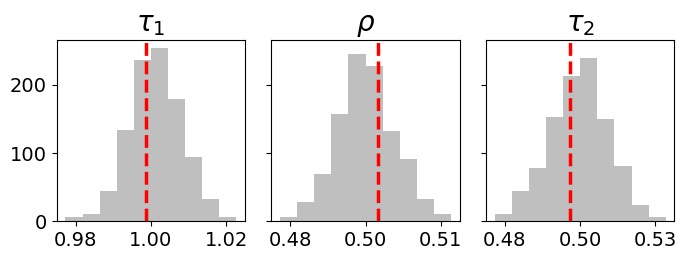

sim bias:  [0.0023, -0.0027, 0.0029]
sim sd:  [0.0064, 0.0066, 0.009]


In [7]:
theta_true = [tau1, rho, tau2]
titles = [r"$\tau_{1}$",r"$\rho$",r"$\tau_{2}$"]
bias_sim_list=[]; sd_sim_list=[]; corr_sim_list=[]
for i in range(1,6):
    cache_dir = f'cache/{cache}/MoM_est_scenario_{i}.txt'
    save_dir = f'image/{cache}/hist_mom_est_scenario_{i}.pdf'
    bias_sim,sd_sim,corr_sim = plot_MOM_est(cache_dir, titles, theta_true, figsize = (7,2.7), save = save_dir)
    bias_sim_list.append(bias_sim); sd_sim_list.append(sd_sim); corr_sim_list.append(corr_sim)

## Asymptotic bias and standard deviation

In [8]:
bias_theory_s1, cov_theory_s1 = clt_seq_fullsib(theta_true,B_list,U_list,J_list,p,factor=10)
sd_theory_s1 = np.sqrt(np.diag(cov_theory_s1))
corr_theory_s1 = cov_theory_s1 / np.outer(sd_theory_s1, sd_theory_s1)
print("\nScenario 1:\nempirical bias: ",bias_sim_list[0],
      "\ntheoretical bias: ",[round(x, 4) for x in bias_theory_s1.tolist()])
print("empirical sd: ",sd_sim_list[0],
      "\ntheoretical sd: ",[round(x, 4) for x in sd_theory_s1.tolist()])
print("\nempirical corr:")
for row in np.round(corr_sim_list[0].to_numpy(), 4).tolist():
    print(" ", row)
print("theoretical corr:")
for row in np.round(corr_theory_s1.numpy(), 4).tolist():
    print(" ", row)

#### Level 2 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 100/100 [00:01<00:00, 72.71it/s]


#### Level 1 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 100/100 [00:02<00:00, 34.09it/s]


Scenario 1:
empirical bias:  [0.002, -0.001, -0.0] 
theoretical bias:  [0.002, -0.001, 0.0]
empirical sd:  [0.0056, 0.0022, 0.0016] 
theoretical sd:  [0.0055, 0.0022, 0.0015]

empirical corr:
  [1.0, -0.6359, -0.0659]
  [-0.6359, 1.0, -0.2754]
  [-0.0659, -0.2754, 1.0]
theoretical corr:
  [1.0, -0.6531, -0.058]
  [-0.6531, 1.0, -0.303]
  [-0.058, -0.303, 1.0]


In [9]:
bias_theory_s2, cov_theory_s2 =  clt_joint_fullsib(theta_true, B_list[0], U_list, J_list, p, scenario = '2', factor = 10)
sd_theory_s2 = np.sqrt(np.diag(cov_theory_s2))
corr_theory_s2 = cov_theory_s2 / np.outer(sd_theory_s2, sd_theory_s2)
print("Scenario 2:\ntheoretical bias: ",[round(x, 4) for x in bias_theory_s2.tolist()],
      "\nempirical bias: ",bias_sim_list[1])
print("theoretical sd: ",[round(x, 4) for x in sd_theory_s2.tolist()],
      "\nempirical sd: ",sd_sim_list[1])
print("\nempirical corr:")
for row in np.round(corr_sim_list[1].to_numpy(), 4).tolist():
    print(" ", row)
print("theoretical corr:")
for row in np.round(corr_theory_s2.numpy(), 4).tolist():
    print(" ", row)

Evaluating deterministic equivalent LSS...: 100%|██████████| 100/100 [00:38<00:00,  2.60it/s]

Scenario 2:
theoretical bias:  [0.0009, -0.003, 0.0048] 
empirical bias:  [0.0012, -0.0031, 0.0047]
theoretical sd:  [0.0049, 0.0072, 0.0134] 
empirical sd:  [0.0049, 0.0073, 0.0136]

empirical corr:
  [1.0, -0.1243, -0.0066]
  [-0.1243, 1.0, -0.9724]
  [-0.0066, -0.9724, 1.0]
theoretical corr:
  [1.0, -0.0818, -0.0639]
  [-0.0818, 1.0, -0.9718]
  [-0.0639, -0.9718, 1.0]


In [10]:
bias_theory_s3, cov_theory_s3 =  clt_joint_fullsib(theta_true, B_list[0], U_list, J_list, p, scenario = '3', factor = 10)
sd_theory_s3 = np.sqrt(np.diag(cov_theory_s3))
corr_theory_s3 = cov_theory_s3 / np.outer(sd_theory_s3, sd_theory_s3)
print("\nScenario 3:\ntheoretical bias: ",[round(x, 4) for x in bias_theory_s3.tolist()],
      "\nempirical bias: ",bias_sim_list[2])
print("theoretical sd: ",[round(x, 4) for x in sd_theory_s3.tolist()],
      "\nempirical sd: ",sd_sim_list[2])
print("\nempirical corr:")
for row in np.round(corr_sim_list[2].to_numpy(), 4).tolist():
    print(" ", row)
print("theoretical corr:")
for row in np.round(corr_theory_s3.numpy(), 4).tolist():
    print(" ", row)

Evaluating deterministic equivalent LSS...: 100%|██████████| 100/100 [00:37<00:00,  2.65it/s]


Scenario 3:
theoretical bias:  [-0.1761, -0.1693, 0.4284] 
empirical bias:  [-0.176, -0.1693, 0.4283]
theoretical sd:  [0.0086, 0.0082, 0.0093] 
empirical sd:  [0.0091, 0.0084, 0.0096]

empirical corr:
  [1.0, -0.6424, 0.4306]
  [-0.6424, 1.0, -0.9291]
  [0.4306, -0.9291, 1.0]
theoretical corr:
  [1.0, -0.6283, 0.4051]
  [-0.6283, 1.0, -0.9255]
  [0.4051, -0.9255, 1.0]


In [11]:
bias_theory_s5, cov_theory_s5 = clt_joint_fullsib(theta_true, B_list[0], U_list, J_list, p, scenario = '5', factor = 10)
sd_theory_s5 = np.sqrt(np.diag(cov_theory_s5))
corr_theory_s5 = cov_theory_s5 / np.outer(sd_theory_s5, sd_theory_s5)
print("\nScenario 5:\ntheoretical bias: ",[round(x, 4) for x in bias_theory_s5.tolist()],
      "\nempirical bias: ",bias_sim_list[4])
print("theoretical sd: ",[round(x, 4) for x in sd_theory_s5.tolist()],
      "\nempirical sd: ",sd_sim_list[4])
print("\nempirical corr:")
for row in np.round(corr_sim_list[4].to_numpy(), 4).tolist():
    print(" ", row)
print("theoretical corr:")
for row in np.round(corr_theory_s5.numpy(), 4).tolist():
    print(" ", row)

Evaluating deterministic equivalent LSS...: 100%|██████████| 100/100 [00:38<00:00,  2.59it/s]


Scenario 5:
theoretical bias:  [0.0023, -0.0027, 0.003] 
empirical bias:  [0.0023, -0.0027, 0.0029]
theoretical sd:  [0.0061, 0.0064, 0.0087] 
empirical sd:  [0.0064, 0.0066, 0.009]

empirical corr:
  [1.0, -0.6805, 0.5289]
  [-0.6805, 1.0, -0.9549]
  [0.5289, -0.9549, 1.0]
theoretical corr:
  [1.0, -0.6579, 0.4993]
  [-0.6579, 1.0, -0.953]
  [0.4993, -0.953, 1.0]


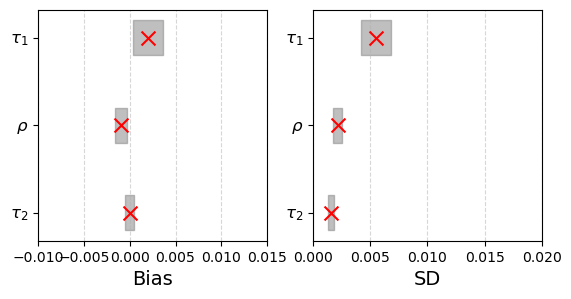

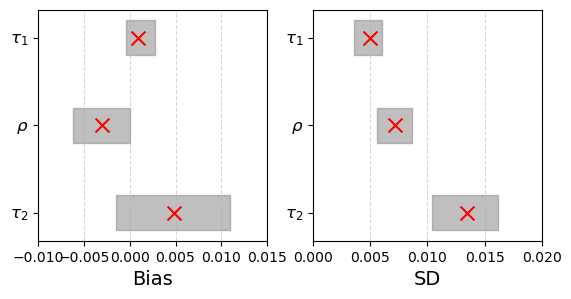

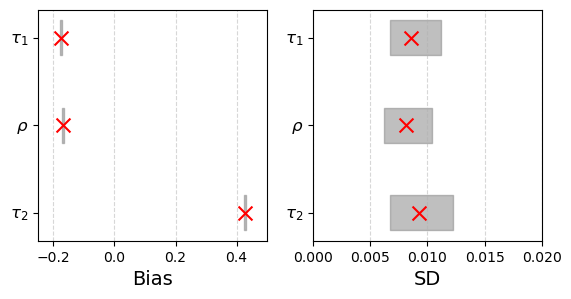

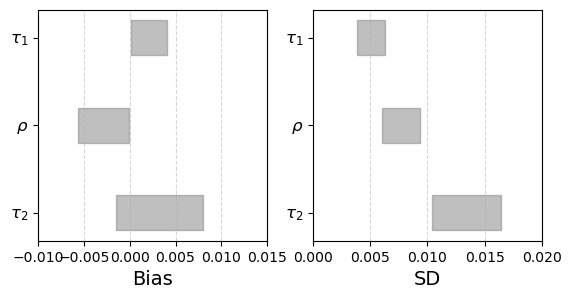

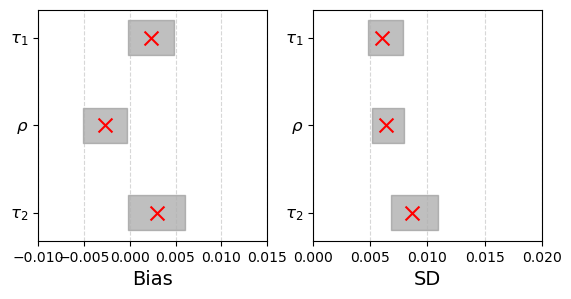

In [12]:
bias_theory_list=[bias_theory_s1,bias_theory_s2,bias_theory_s3,[],bias_theory_s5]; 
sd_theory_list=[sd_theory_s1,sd_theory_s2,sd_theory_s3,[],sd_theory_s5]

theta_true = [tau1, rho, tau2]
titles = [r"$\tau_{1}$",r"$\rho$",r"$\tau_{2}$"]
bias_xlim=[-0.01,0.015]; sd_xlim=[0,0.02]

for i in range(1,6):
    cache_dir = f'cache/{cache}/MoM_est_scenario_{i}.txt'
    save_dir = f'image/{cache}/conf_bias_sd_scenario_{i}.pdf'
    if i==3:
        plot_conf_bias_sd(cache_dir, titles, theta_true, bias_theory_list[i-1], sd_theory_list[i-1],
                          save = save_dir,bias_xlim=[-0.25,0.5],sd_xlim=sd_xlim)
    else:
        plot_conf_bias_sd(cache_dir, titles, theta_true, bias_theory_list[i-1],sd_theory_list[i-1], 
                          save = save_dir,bias_xlim=bias_xlim,sd_xlim=sd_xlim)